# Customer Segmentation with K-Means Clustering

**AI Engineering Track — Customer Segmentation Project**

One year of raw retail transaction data is turned into clear, well-defined
customer personas using unsupervised learning (RFM features + K-Means + PCA).

In [3]:

import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


## Step 0 — Load and Inspect the Raw Data

The raw file is **transaction-level**: one row per purchase, not per customer.

In [8]:
class DataLoader:
    """Loads the raw transaction-level CSV and parses dates."""

    def __init__(self, filepath: str):
        self.filepath = filepath
        self.raw_df = None

    def load(self) -> pd.DataFrame:
        self.raw_df = pd.read_csv(self.filepath)
        self.raw_df['transaction_date'] = pd.to_datetime(self.raw_df['transaction_date'])
        return self.raw_df

    def summary(self):
        df = self.raw_df
        print(f"Shape: {df.shape}")
        print(f"Unique customers: {df['customer_id'].nunique()}")
        print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")



## Step 1 — Build RFM Features

For each customer we compute three metrics from the raw transactions:

- **Recency** — days since their most recent purchase (measured from one day
  after the last date in the dataset, our "snapshot" date)
- **Frequency** — total number of transactions
- **Monetary** — total amount spent across all transactions

In [3]:
snapshot_date = df['transaction_date'].max() + timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('transaction_date', 'count'),
    Monetary=('amount', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}  (one row per customer)")
rfm.head()

RFM table shape: (300, 4)  (one row per customer)


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,"5,172.45"
1,5002,23,18,"6,158.98"
2,5003,37,3,654.12
3,5004,5,35,"31,050.88"
4,5005,26,16,"5,700.91"


In [4]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,300.00,300.00,300.00
mean,54.66,12.21,"6,264.08"
std,68.26,10.64,"9,659.80"
min,1.00,1.00,71.92
25%,12.00,4.00,653.49
50%,30.50,10.00,"3,427.15"
75%,73.25,16.00,"5,544.70"
max,337.00,45.00,"39,424.12"


The spread is large: Recency ranges from a few days to almost a full year,
Frequency from a single purchase to dozens, and Monetary from under $100 to
nearly $40,000. This is exactly the kind of variation that should separate
customers into meaningfully different groups.

## Step 2 — Scale the Features

Recency (days), Frequency (counts), and Monetary (dollars) live on very
different numeric scales. Without standardizing them, Monetary would
dominate the distance calculations K-Means relies on. We standardize each
feature to mean 0, standard deviation 1.

In [5]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.describe().round(2)

,Recency,Frequency,Monetary
count,300.00,300.00,300.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-0.79,-1.06,-0.64
25%,-0.63,-0.77,-0.58
50%,-0.35,-0.21,-0.29
75%,0.27,0.36,-0.07
max,4.14,3.09,3.44


## Step 3 — Find the Right Number of Clusters (Elbow + Silhouette)

We test k = 2 through 8 and look at two signals together:

- **Inertia (elbow method)** — how tightly points cluster around their
  centroid; we look for the point where adding more clusters stops
  giving a big improvement.
- **Silhouette score** — how well-separated the clusters are; higher is
  better, and it penalizes k values that just add clusters without real
  structure.

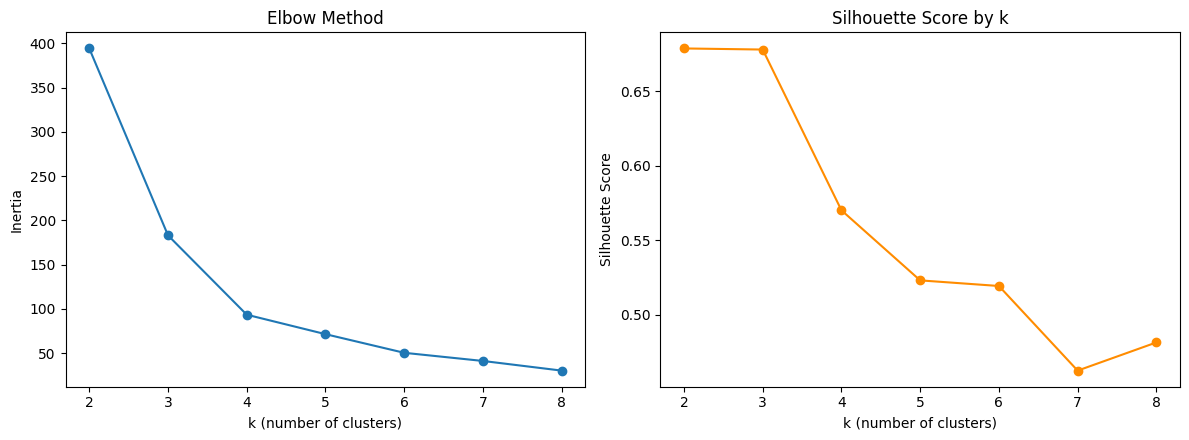

k=2:  inertia=   394.2   silhouette=0.679
k=3:  inertia=   183.0   silhouette=0.678
k=4:  inertia=    93.4   silhouette=0.570
k=5:  inertia=    71.4   silhouette=0.523
k=6:  inertia=    50.3   silhouette=0.519
k=7:  inertia=    41.1   silhouette=0.463
k=8:  inertia=    30.2   silhouette=0.481


In [6]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}:  inertia={i:8.1f}   silhouette={s:.3f}")

### Reasoning for choosing k

- Silhouette peaks at k=2 (0.679) and k=3 (0.678) — essentially tied —
  then declines steadily. That tells us the data is not naturally 5+
  groups; the strong structure sits at the low end of k.
- The elbow plot shows two large drops: k=2→3 and k=3→4 (inertia roughly
  halves each time), with the curve flattening noticeably from k=4
  onward. That places the elbow around **k=4**.
- k=4 still has a respectable silhouette score (0.57 — well above the
  noisy region at k≥6), while giving one more degree of separation than
  k=3.
- Critically, when we inspect the actual RFM averages per cluster (next
  section), k=4 produces four segments that are each clearly
  interpretable as a distinct business persona — which k=2 or k=3 would
  blur together. That business-sense check is the deciding factor, in
  line with the brief's guidance that a justified choice beats picking
  the mathematically "best" score blindly.

**Chosen k = 4.**

## Step 4 — Fit K-Means with k=4

In [7]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customers'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,71.60,4.20,752.50,111
1,8.40,35.00,"29,683.60",40
2,263.40,2.10,320.50,21
3,20.20,13.70,"4,700.20",128


## Step 5 — Visualize the Clusters with PCA

The three RFM dimensions are reduced to 2 principal components so the
clusters can be plotted and visually inspected.

In [8]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

Explained variance ratio: [0.75  0.237]
Total variance captured in 2D: 98.7%


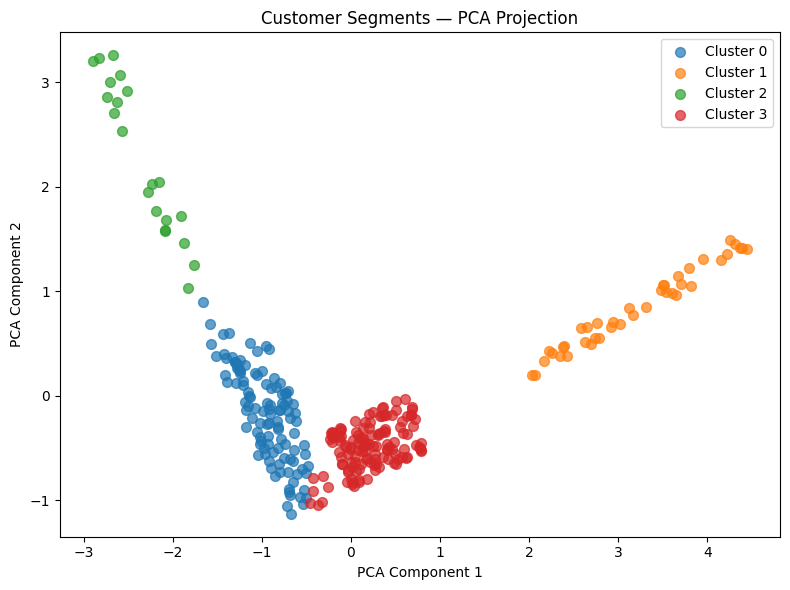

In [9]:
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10.colors
for c in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == c]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {c}',
                alpha=0.7, s=50, color=colors[c])
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments — PCA Projection')
plt.legend()
plt.tight_layout()
plt.show()

The four clusters are visually well-separated in the PCA projection
(the 2 components capture ~99% of the variance in the scaled RFM data),
confirming that K-Means found genuine structure rather than an arbitrary
split.

## Step 6 — Name the Personas

Looking at the average Recency / Frequency / Monetary values per cluster:

In [10]:
cluster_profile.sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary,Customers
Cluster,,,,
1,8.40,35.00,"29,683.60",40
3,20.20,13.70,"4,700.20",128
0,71.60,4.20,752.50,111
2,263.40,2.10,320.50,21


| Cluster | Recency (days) | Frequency | Monetary | Persona |
|---|---|---|---|---|
| 1 | ~8 | ~35 | ~$29,700 | **VIP** |
| 3 | ~20 | ~14 | ~$4,700 | **Loyal / Regular** |
| 0 | ~72 | ~4 | ~$750 | **New / Occasional** |
| 2 | ~263 | ~2 | ~$320 | **Dormant** |

*(Exact cluster numbers can shift slightly on re-runs — the table above
regenerates from `cluster_profile.sort_values('Monetary', ascending=False)`,
so always match personas to numbers using this table, not fixed IDs.)*

---
## Persona Summary

**VIP** — These customers buy constantly (about 35 transactions each) and
spend far more than anyone else (~$29,700 on average), while their most
recent purchase was only about a week ago. They are the core revenue
driver despite being a small group. The business should protect this
segment aggressively: dedicated account support, early access to new
products, and loyalty perks — losing even one of these customers has an
outsized revenue impact.

**Loyal / Regular** — A solid middle tier: recent purchases (~20 days
ago), a healthy ~14 transactions, and ~$4,700 spent. They are engaged and
reliable but not yet VIPs. This is the best group to invest marketing
spend in for upsell — targeted bundles, category recommendations, and
occasional loyalty incentives can push a meaningful share of them toward
VIP status.

**New / Occasional** — Bought a handful of times (~4 transactions,
~$750 total) with a moderate recency (~72 days), suggesting either
newer customers still forming a habit or occasional shoppers who buy
only when something specific catches their eye. Light, low-cost
re-engagement (category-specific promotions, welcome offers) is the
right move here — spending heavily to win them over isn't justified yet.

**Dormant** — Haven't purchased in roughly 9 months (~263 days), with
very few transactions (~2) and minimal spend (~$320) historically. This
is the largest revenue-recovery opportunity in raw customer count but the
lowest priority per customer. A low-cost win-back campaign (a single
well-timed discount or "we miss you" email) makes sense; anything more
expensive than that isn't worth the expected return for this group.